In [ ]:


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/crop_project/best_multimodal_model.keras"
)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [ ]:
import os

folder_path = "/content/drive/MyDrive/crop_project/Original_Image/Bacterial Leaf Spot"

print(os.listdir(folder_path)[:10])

['Bacterial (1).jpg', 'Bacterial (10).jpg', 'Bacterial (100).jpg', 'Bacterial (101).jpg', 'Bacterial (102).jpg', 'Bacterial (103).jpg', 'Bacterial (104).jpg', 'Bacterial (105).jpg', 'Bacterial (106).jpg', 'Bacterial (107).jpg']


In [ ]:
import os

image_path = "/content/drive/MyDrive/crop_project/Original_Image/Bacterial Leaf Spot/Bacterial (1).jpg"

print(os.path.exists(image_path))

True


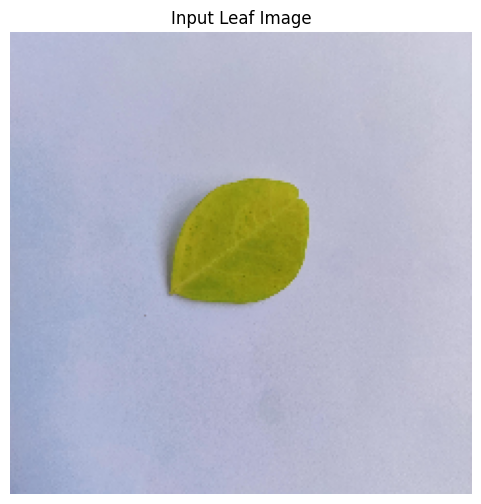

Predicted Disease : Bacterial Leaf Spot
Confidence        : 99.90%
Temperature       : 32 °C
Weather           : Sunny

Prediction Probabilities:

Bacterial Leaf Spot      : 99.90%
Cercospora Leaf Spot     : 0.00%
Healthy                  : 0.01%
Yellow                   : 0.09%


In [ ]:
# ==========================================================
# Crop Disease Prediction using Image + Weather
# ==========================================================

# -----------------------------
# 1. Mount Google Drive
# -----------------------------

# -----------------------------
# 2. Import Libraries
# -----------------------------


# -----------------------------
# 3. Load Trained Model
# -----------------------------

# ==========================================================
# 4. Give Image Path
# ==========================================================

image_path = "/content/drive/MyDrive/crop_project/Original_Image/Bacterial Leaf Spot/Bacterial (1).jpg"

# Check image exists
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found:\n{image_path}")

# ==========================================================
# 5. Enter Weather Information
# ==========================================================

temperature = 32

weather_name = "Sunny"

weather_dict = {
    "Cloudy": 0,
    "Partly Cloudy": 1,
    "Sunny": 2
}

weather = weather_dict[weather_name]

# ==========================================================
# 6. Read and Preprocess Image
# ==========================================================

img = cv2.imread(image_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (224,224))

img = img.astype(np.float32) / 255.0

image = np.expand_dims(img, axis=0)

# ==========================================================
# 7. Prepare Weather Input
# ==========================================================

weather_input = np.array([[temperature, weather]], dtype=np.float32)

# ==========================================================
# 8. Predict Disease
# ==========================================================

prediction = model.predict([image, weather_input], verbose=0)

predicted_class = np.argmax(prediction)

confidence = float(np.max(prediction) * 100)

# ==========================================================
# 9. Disease Names
# ==========================================================

class_names = [
    "Bacterial Leaf Spot",
    "Cercospora Leaf Spot",
    "Healthy",
    "Yellow"
]

# ==========================================================
# 10. Display Image
# ==========================================================

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Input Leaf Image")
plt.show()

# ==========================================================
# 11. Display Prediction
# ==========================================================

print("="*60)
print("Predicted Disease :", class_names[predicted_class])
print("Confidence        : {:.2f}%".format(confidence))
print("Temperature       :", temperature, "°C")
print("Weather           :", weather_name)
print("="*60)

# ==========================================================
# 12. Probability of Every Class
# ==========================================================

print("\nPrediction Probabilities:\n")

for i, disease in enumerate(class_names):
    print(f"{disease:25s}: {prediction[0][i]*100:.2f}%")

Saving Cercospora (1).jpg to Cercospora (1) (1).jpg


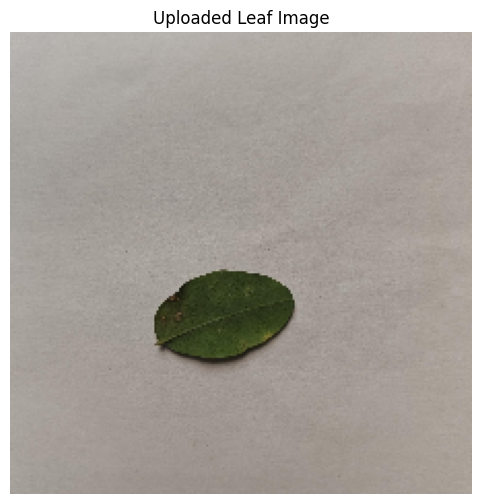

Enter Temperature (°C): 34
Enter Weather (Sunny / Cloudy / Partly Cloudy): Sunny

        MULTIMODAL CROP DISEASE PREDICTION RESULT
Predicted Disease : Cercospora Leaf Spot
Confidence        : 98.76%
Temperature       : 34.0 °C
Weather           : Sunny

Cause:
Fungal infection caused by Cercospora species.

Symptoms:
Circular brown or gray spots with dark borders on leaves.

Treatment:
Apply recommended fungicide and remove infected leaves.

Prevention:
Maintain proper spacing between plants and reduce leaf wetness.

Prediction Probabilities:

Bacterial Leaf Spot       : 0.78%
Cercospora Leaf Spot      : 98.76%
Healthy                   : 0.45%
Yellow                    : 0.00%


In [ ]:
# ==========================================================
# Crop Disease Prediction using Image + Weather
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================================================
# Upload Image
# ==========================================================

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# ==========================================================
# Read and Preprocess Image
# ==========================================================

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))
img = img.astype(np.float32) / 255.0

image = np.expand_dims(img, axis=0)

# Display uploaded image
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Uploaded Leaf Image")
plt.axis("off")
plt.show()

# ==========================================================
# Enter Weather Information
# ==========================================================

temperature = float(input("Enter Temperature (°C): "))

weather_name = input(
    "Enter Weather (Sunny / Cloudy / Partly Cloudy): "
).strip()

weather_dict = {
    "Cloudy":0,
    "Partly Cloudy":1,
    "Sunny":2
}

weather = weather_dict[weather_name]

weather_input = np.array([[temperature, weather]], dtype=np.float32)

# ==========================================================
# Predict Disease
# ==========================================================

prediction = model.predict([image, weather_input], verbose=0)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction) * 100

# ==========================================================
# Disease Names
# ==========================================================

class_names = [
    "Bacterial Leaf Spot",
    "Cercospora Leaf Spot",
    "Healthy",
    "Yellow"
]

# ==========================================================
# Disease Information
# ==========================================================

disease_info = {

    "Bacterial Leaf Spot": {

        "Cause":
        "Bacterial infection caused by Xanthomonas species.",

        "Symptoms":
        "Small water-soaked spots that later become brown with yellow margins.",

        "Treatment":
        "Spray copper-based bactericide. Remove infected leaves and avoid overhead irrigation.",

        "Prevention":
        "Use disease-free seeds, maintain field sanitation, and avoid excess moisture."
    },

    "Cercospora Leaf Spot": {

        "Cause":
        "Fungal infection caused by Cercospora species.",

        "Symptoms":
        "Circular brown or gray spots with dark borders on leaves.",

        "Treatment":
        "Apply recommended fungicide and remove infected leaves.",

        "Prevention":
        "Maintain proper spacing between plants and reduce leaf wetness."
    },

    "Healthy": {

        "Cause":
        "No disease detected.",

        "Symptoms":
        "Leaves are green and healthy.",

        "Treatment":
        "No treatment is required.",

        "Prevention":
        "Continue proper irrigation, balanced fertilization, and regular crop monitoring."
    },

    "Yellow": {

        "Cause":
        "Yellowing may occur due to nutrient deficiency or disease.",

        "Symptoms":
        "Leaves become yellow and plant growth may slow.",

        "Treatment":
        "Apply appropriate nutrients after checking soil conditions and manage any underlying disease.",

        "Prevention":
        "Maintain soil fertility, proper watering, and regular crop inspection."
    }
}

# ==========================================================
# Display Prediction Result
# ==========================================================

predicted_disease = class_names[predicted_class]

print("\n" + "="*65)
print("        MULTIMODAL CROP DISEASE PREDICTION RESULT")
print("="*65)

print(f"Predicted Disease : {predicted_disease}")
print(f"Confidence        : {confidence:.2f}%")
print(f"Temperature       : {temperature} °C")
print(f"Weather           : {weather_name}")

print("\nCause:")
print(disease_info[predicted_disease]["Cause"])

print("\nSymptoms:")
print(disease_info[predicted_disease]["Symptoms"])

print("\nTreatment:")
print(disease_info[predicted_disease]["Treatment"])

print("\nPrevention:")
print(disease_info[predicted_disease]["Prevention"])

print("="*65)

# ==========================================================
# Prediction Probabilities
# ==========================================================

print("\nPrediction Probabilities:\n")

for i in range(len(class_names)):
    print(f"{class_names[i]:25s} : {prediction[0][i]*100:.2f}%")